# QAOA Example (MaxCut)

这里展示如何使用 `cqlib-algorithm` 中的 QAOA 求解 MaxCut 问题。

In [10]:
from cqlib_algorithm.problems.maxcut import MaxCut
from cqlib_algorithm.mappings.convert import maxcut_to_qubo, qubo_to_ising
from cqlib_algorithm.visualization.maxcut_plot import plot_maxcut
from cqlib_algorithm.execution import LocalRunner
from cqlib_algorithm.algorithms.qaoa import QAOASolver, QAOAConfig
from cqlib_algorithm.optimizers.options import OptimizerOptions
print('Imports ready')

Imports ready


## 1. 定义 MaxCut 实例

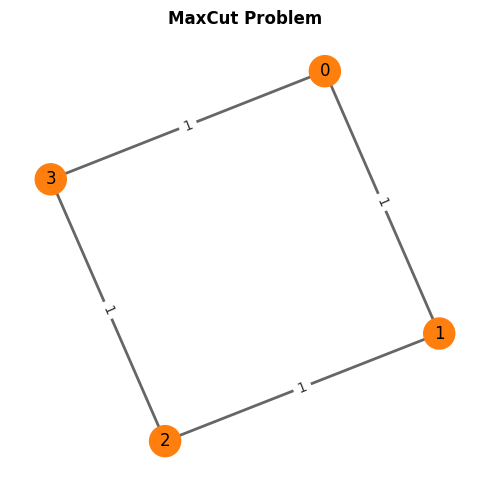

In [11]:
weights =  {(0,1):1, (1,2):1, (2,3):1, (3,0):1}
mc = MaxCut(n=4, weights=weights)
plot_maxcut(n=mc.n, weights=mc.weights, partition={}, title='MaxCut Problem')

## 2. Maxcut → QUBO

In [13]:
qubo  = maxcut_to_qubo(mc)
print(qubo)

========== [ QUBO ] ==========
Q = [
 [0.000, -2.000, 0.000, -2.000]
 [-2.000, 0.000, -2.000, 0.000]
 [0.000, -2.000, 0.000, -2.000]
 [-2.000, 0.000, -2.000, 0.000]
]
c = [2.000, 2.000, 2.000, 2.000]
offset = 0.000



## 3. QUBO → Ising

In [14]:
ising = qubo_to_ising(qubo)
print(ising)

========== [ Ising Hamiltonian ] ==========
Paulis = ['IIZZ', 'ZIIZ', 'IZZI', 'ZZII'],
coeffs = [0.500, 0.500, 0.500, 0.500]
offset = -2.000



## 4. 运行 QAOA（LocalRunner）

[iter=  1] f=0.732 theta=[0.797, 0.803, 0.803, 0.197, 0.203, 0.203]
[iter=  2] f=-1.368 theta=[0.259, 0.265, 1.341, -0.341, -0.335, -0.335]
[iter=  3] f=-1.274 theta=[0.413, 0.111, 1.495, -0.187, -0.489, -0.489]
[iter=  4] f=0.654 theta=[0.759, 0.457, 1.149, 0.159, -0.143, -0.143]
[iter=  5] f=-0.018 theta=[0.627, 0.325, 1.017, 0.291, -0.275, -0.011]
[iter=  6] f=-0.412 theta=[0.810, 0.508, 0.835, 0.108, -0.457, 0.171]
[iter=  7] f=-0.748 theta=[0.915, 0.613, 0.730, 0.003, -0.352, 0.276]
[iter=  8] f=-0.862 theta=[0.959, 0.657, 0.685, 0.048, -0.308, 0.321]
[iter=  9] f=-0.688 theta=[0.511, 0.209, 1.134, -0.401, 0.140, 0.769]
[iter= 10] f=-0.934 theta=[0.309, 0.007, 0.932, -0.602, -0.061, 0.971]
[iter= 11] f=-0.940 theta=[0.315, 0.013, 0.926, -0.596, -0.055, 0.965]
[iter= 12] f=-0.948 theta=[0.112, 0.216, 0.723, -0.393, 0.148, 1.168]
[iter= 13] f=-0.952 theta=[0.142, 0.186, 0.692, -0.363, 0.178, 1.198]
[iter= 14] f=-1.074 theta=[0.230, 0.098, 0.605, -0.276, 0.091, 1.286]
[iter= 15] f=-1

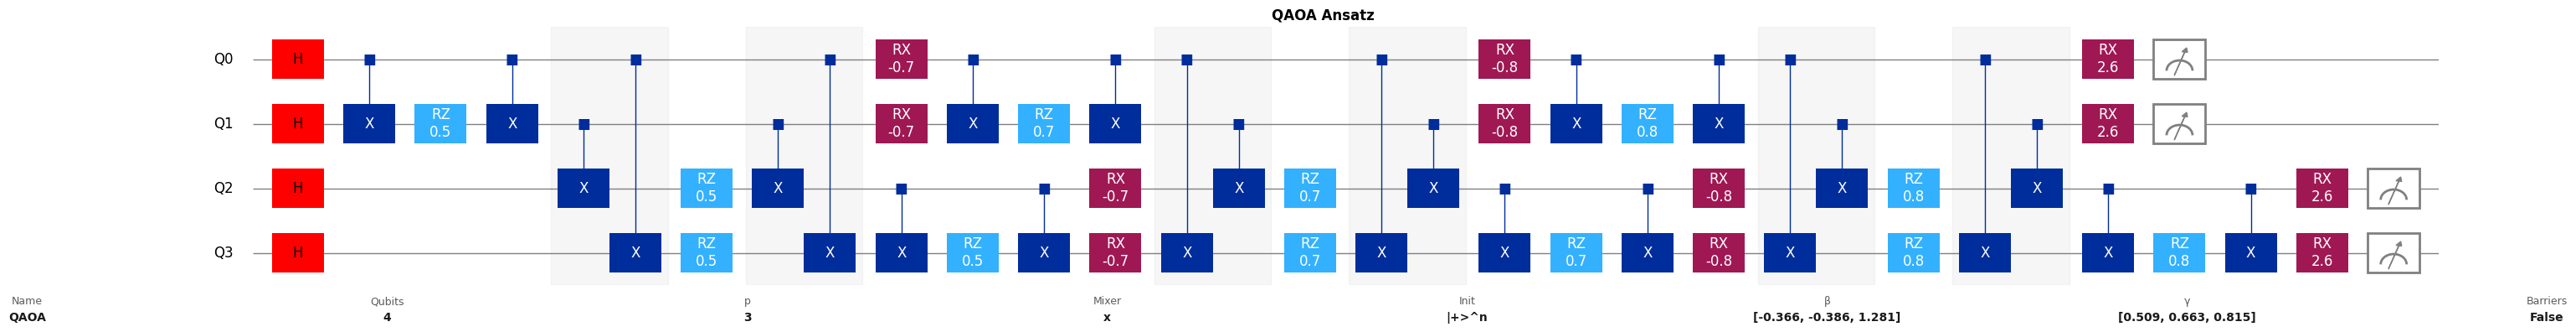

In [15]:
opt_cfg = OptimizerOptions(name="spsa", options={"maxiter": 50, "a": 0.2, "c": 0.2})
solver = QAOASolver(ising, 
                    runner=LocalRunner(), 
                    qaoa_cfg=QAOAConfig(reps=3, mixer="x"), 
                    opt_cfg=opt_cfg)
res = solver.run()

## 5. 可视化：运行结果

In [16]:
res.print_result()


========== [ Experiment Information ] ==========
任务ID     : 20251011180117
shots 数量 : 1000

========== [ Optimize Configs ] ==========
runner      : LocalRunner
qaoa_cfg    : {'reps': 3, 'mixer': 'x', 'shots': 1000, 'name': 'QAOA', 'wrap_angles': True, 'need_transpile': None, 'verbose': True}
opt_cfg    : {'name': 'spsa', 'options': {'maxiter': 50, 'a': 0.2, 'c': 0.2}}

========== [ Measurement Results ] ==========
probability : {'1010': 0.511, '0101': 0.472, '0001': 0.003, '0111': 0.003, '0010': 0.002, '0100': 0.002, '1000': 0.002, '1101': 0.002, '0011': 0.001, '1001': 0.001, '1011': 0.001}


## 6. 可视化：迭代曲线与概率分布

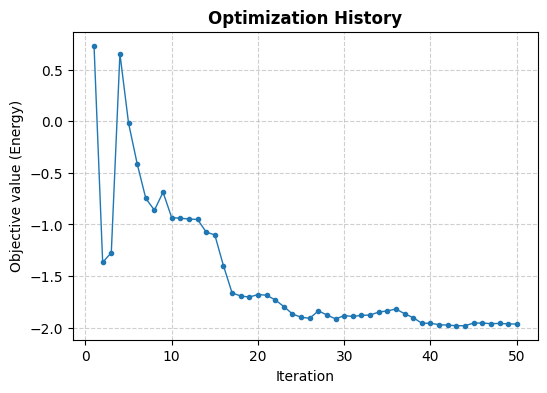

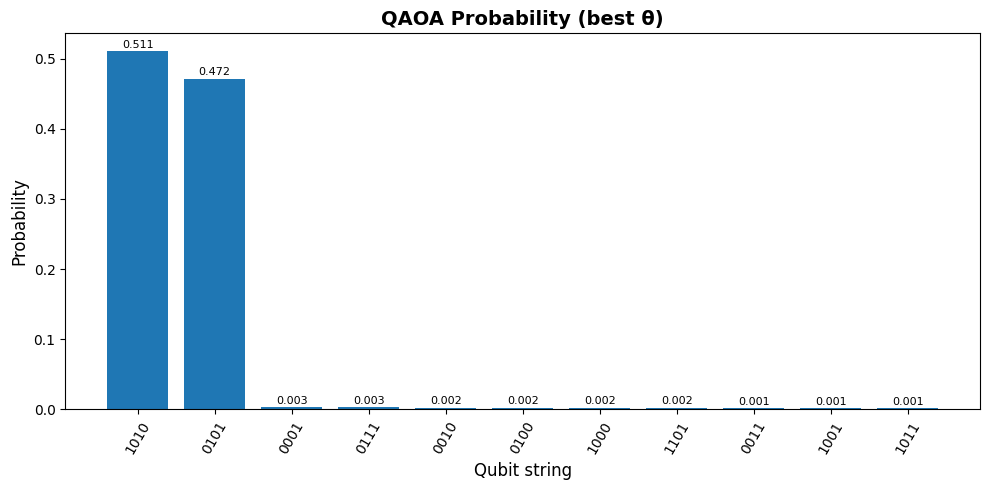

In [17]:
res.plot_history(title="Optimization History")
res.plot_probability(title="QAOA Probability (best θ)", topk=20)

## 7. 可视化：最优 MaxCut 解


========== [ Optimization Results ] ==========
Best gammas : [0.509, 0.663, 0.815]
Best betas  : [-0.366, -0.386, 1.281]
Best energy : -1.966
Best Qubit string:  1010
Best solution: [0, 2]
Max-Cut value: 4.000


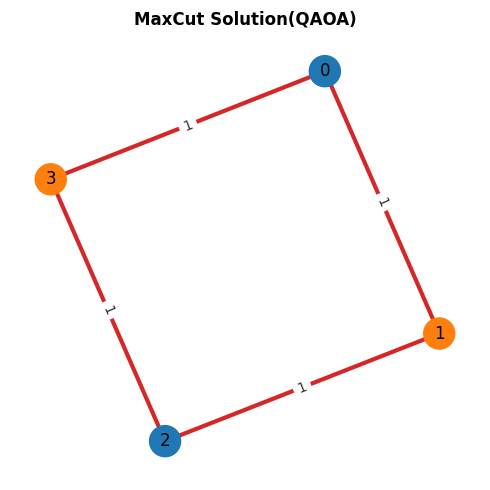

[0, 2]

In [18]:
res.plot_maxcut_solution(n=mc.n, weights=mc.weights, title="MaxCut Solution(QAOA)")

### 可选：对接中电信“天衍”量子计算云平台后端
将 `LocalRunner()` 替换为 `TianYanRunner()`：
```python
from cqlib_algorithm.execution import TianYanRunner
runner = TianYanRunner(login_key='YOUR_KEY', machine='tianyan_sw')
```
